In [38]:
import os, sys, glob
import numpy as np
import sunpy.map
import drms
from astropy.io import fits
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

from astropy.convolution import convolve
from scipy.special import j1


In [93]:
tracing.FortranTracer()

RuntimeError: Using FortranTracer requires the streamtracer module, but streamtracer could not be loaded

In [64]:
from astropy import units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord
import pfsspy
from pfsspy import tracing
import matplotlib.colors as mcolor

from diagnostics import pfss, plot_pfss


In [11]:
SRC_PATH = (Path.cwd() / "../src").resolve()
sys.path.insert(0, str(SRC_PATH))

In [47]:
from config.config import Config

# Code

##  Path definitions

In [66]:
carrington_number = 2284 # 2284, 2285, 2286, 2287

In [67]:
root = Path.cwd()
path = root / '../data/pfss_test/'
fname_phi = f'synopMr_CR{carrington_number}.fits'



In [68]:
fname = "synopMr.fits"
series="hmi.synoptic_mr_polfil_720s"
segment="Mr_polfil"
small = False

In [70]:
############################
####### GET PHI DATA #######
############################

synop_phi  = fits.open(path / fname_phi)

phi_img   = synop_phi[0].data
if not small: 
    phi_table = synop_phi[1].data

# Define Carrington rotation number
#carrington_number = int(synop_phi[0].header["CAR_ROT"])
outname = f"{carrington_number}"


############################
####### GET HMI DATA #######
############################

# Create DRMS client
c = drms.Client(email="loeschl@mps.mpg.de")#, verbose=True)

datapath_hmi = os.path.join(root, f"../data/tmp/CR{carrington_number}/")
os.makedirs(datapath_hmi, exist_ok=True)

# Query JSOC for that rotation
q = c.query(f"{series}[{carrington_number}]", seg=segment)
fname_hmi = q[segment][0].split('/')[-1]

try:
    file_hmi  = glob.glob(f"{datapath_hmi}*{fname_hmi}")[0]
    synop_hmi = fits.open(file_hmi)
except IndexError:
    # Download the FITS file
    result = c.export(f"{series}[{carrington_number}]", method='url', protocol='fits')
    result.download(datapath_hmi)
    file_hmi  = glob.glob(f"{datapath_hmi}*{fname_hmi}")[0]
    synop_hmi = fits.open(file_hmi)

try: 
    hmi_img = synop_hmi[1].data   

    # create mask of NaN values in phi_img and fill them with hmi_img values
    mask_polfil = np.isnan(phi_img)
    phi_polfil  = np.where(mask_polfil, hmi_img, phi_img)    

    # aggressive HMI pole filling
    #phi_polfil[:40, :]  = hmi_img[:40, :]
    #phi_polfil[1400: :] = hmi_img[1400:, :]

    #synop_phi[0].header["CUNIT2"] = "deg" # "Sine Latitude"

    primary_hdu = fits.PrimaryHDU()

    polfil_hdu = fits.CompImageHDU(data=phi_polfil, 
                                    header=synop_phi[0].header, 
                                    compression_type='RICE_1')

    polfil_hdul = fits.HDUList([primary_hdu, polfil_hdu])
    polfil_hdul.writeto(os.path.join(path, "synopMr_polfil.fits"), overwrite=True)

    # show filled synoptic map 
    #plt.imshow(phi_polfil, cmap='hmimag', vmin=-1500, vmax=1500, origin='lower')
    #plt.show()

except IndexError:
    # non polfil data
    hmi_img = synop_hmi[0].data

## Function definitions

In [13]:
def airy_psf(size, radius_px):
    y, x = np.indices((size, size))
    r = np.sqrt((x - size//2)**2 + (y - size//2)**2)
    kr = np.pi * r / radius_px
    psf = np.ones_like(r)
    mask = kr != 0
    psf[mask] = (2 * j1(kr[mask]) / kr[mask])**2
    return psf / psf.sum()

In [14]:
def airy_psf_v2(size, fwhm):
    """
    Create an Airy disk PSF.
    
    size: int, width/height of PSF kernel (pixels)
    fwhm: float, FWHM in pixels
    """
    y, x = np.indices((size, size)) - size // 2
    r = np.sqrt(x**2 + y**2)
    
    # Convert FWHM to first zero (approximation)
    r0 = fwhm / 1.028  # Airy FWHM ≈ 1.028 * lambda / D
    
    r_norm = np.pi * r / r0
    psf = (2 * j1(r_norm) / r_norm)**2
    psf[r==0] = 1.0  # handle division by zero at center
    psf /= psf.sum()
    return psf

In [15]:
hmi_segment = synop_cr2284[1].data[synop_cr2284[1].data['SRC'] == 'HMI']

In [16]:
# table is going right to left  -> invert
hmi_end = int(hmi_segment['CRLN_START'][0]*10)
hmi_start = int(hmi_segment['CRLN_END'][0]*10)
hmi_start, hmi_end


(786, 2529)

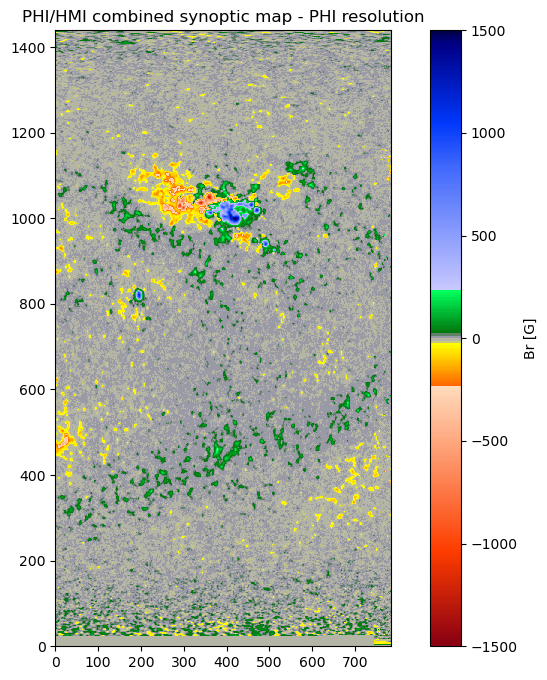

In [72]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 8), nrows=1, ncols=1, sharex=True, sharey=True)
im1 = ax.imshow(phi_polfil[:,:hmi_start], vmin=-1500, vmax=1500, cmap="hmimag", interpolation='None', origin='lower', label='PHI CR')

ax.set_title('PHI/HMI combined synoptic map - PHI resolution')

ax.set_facecolor('lightgray')

fig.colorbar(im1, label='Br [G]')

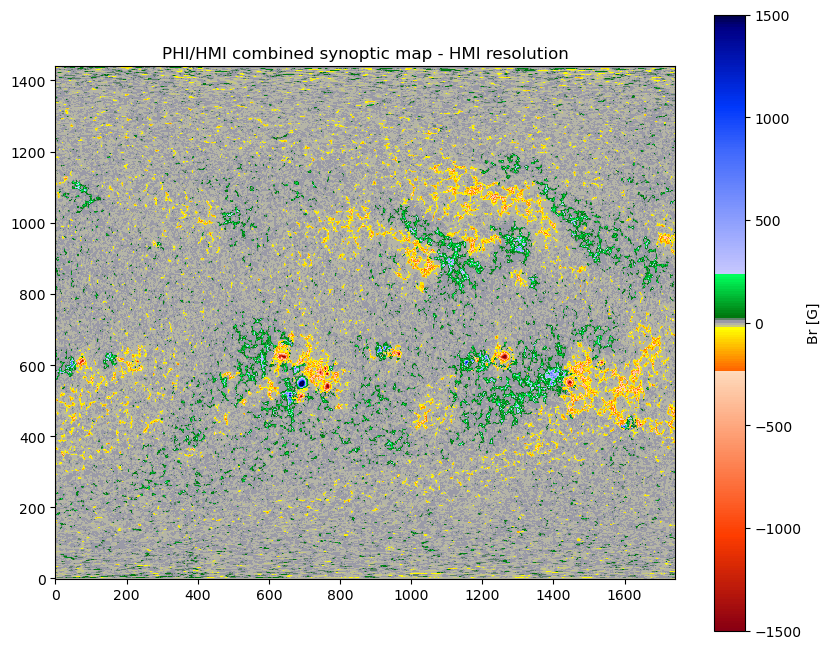

In [73]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 8), nrows=1, ncols=1, sharex=True, sharey=True)
im1 = ax.imshow(phi_polfil[:,hmi_start:hmi_end], vmin=-1500, vmax=1500, cmap="hmimag", interpolation='None', origin='lower', label='PHI CR')

ax.set_title('PHI/HMI combined synoptic map - HMI resolution')

ax.set_facecolor('lightgray')

fig.colorbar(im1, label='Br [G]')

## PSF Kernel

In [74]:
# Set up pixelscale info from cdelt keyword (currently manual!)
cdelt_phi_cr2284 = 3.5748234469 # CR 2284
cdelt_phi_cr2285 = 3.5748234469 # CR 2285
cdelt_phi_cr2286 = 3.5748234469 # CR 2286
cdelt_phi_cr2287 = 3.5748234469 # CR 2287

cdelt_hmi = 0.504032
cdelt_phi = cdelt_phi_cr2284

In [75]:
theta_fdt = (1.22 * (617 * 1e-9)/0.0175)#*(24*3600)
theta_fdt_arcsec = np.degrees(theta_fdt)*(3600) 
theta_fdt_arcsec

np.float64(8.872215443110818)

In [76]:
theta_hmi = (1.22 * (617 * 1e-9)/0.14)#*(24*3600)
theta_hmi_arcsec = np.degrees(theta_hmi)*(3600) 
theta_hmi_arcsec

np.float64(1.1090269303888523)

In [77]:
# 1800 px in remapped xdim. 3820 px solar disk in HMI: 1910 arcsec solar diameter / 0.504 arcsec/px = 3820 px
hmi_degr = 1800/3820.
print(f'HMI plate scale on reprojected/remapped frame {hmi_degr:.4f} arc/px') 

HMI plate scale on reprojected/remapped frame 0.4712 arc/px


In [78]:
fwhm_final = theta_fdt_arcsec/theta_hmi_arcsec
print(f'FWHM difference between HMI and PHI airy disks is a factor {fwhm_final}')

FWHM difference between HMI and PHI airy disks is a factor 8.0


In [79]:
# FWHM_final = FWHM_existing + FWHM_kernel
fwhm_existing = hmi_degr * theta_fdt_arcsec/theta_hmi_arcsec
fwhm_kernel = np.sqrt(fwhm_final**2 - fwhm_existing**2)

print(f"Remaining blur as FWHM kernel size {fwhm_kernel:.2f} px")

Remaining blur as FWHM kernel size 7.06 px


In [107]:
size = 65
halfsize = size//2
size, halfsize

(65, 32)

In [100]:
psf_to_fdt  = airy_psf_v2(size, fwhm_kernel)

/tmp/ipykernel_10014/502814624.py:15: RuntimeWarning: invalid value encountered in divide
  psf = (2 * j1(r_norm) / r_norm)**2


In [113]:
hmi_conv = convolve(phi_polfil[:,hmi_start-halfsize:hmi_end+halfsize], psf_to_fdt, boundary='fill', fill_value=np.nan, normalize_kernel=True)

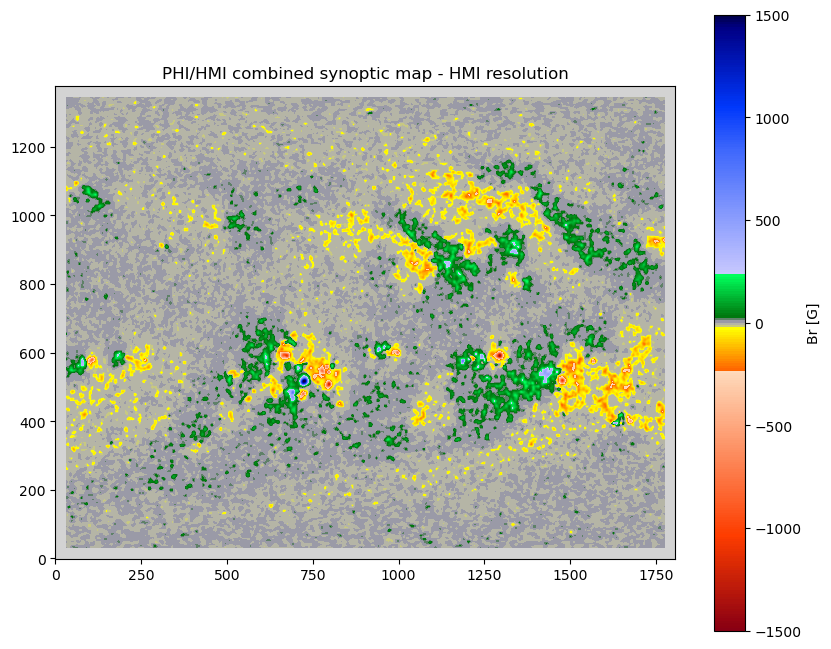

In [112]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 8), nrows=1, ncols=1, sharex=True, sharey=True)
im1 = ax.imshow(hmi_conv, vmin=-1500, vmax=1500, cmap="hmimag", interpolation='None', origin='lower', label='PHI CR')

ax.set_title('PHI/HMI combined synoptic map - HMI resolution')

ax.set_facecolor('lightgray')

fig.colorbar(im1, label='Br [G]')

In [116]:
phi_polfil_degr = phi_polfil.copy()

In [117]:
phi_polfil_degr[halfsize:-halfsize,hmi_start:hmi_end] = hmi_conv[halfsize:-halfsize,halfsize:-halfsize]

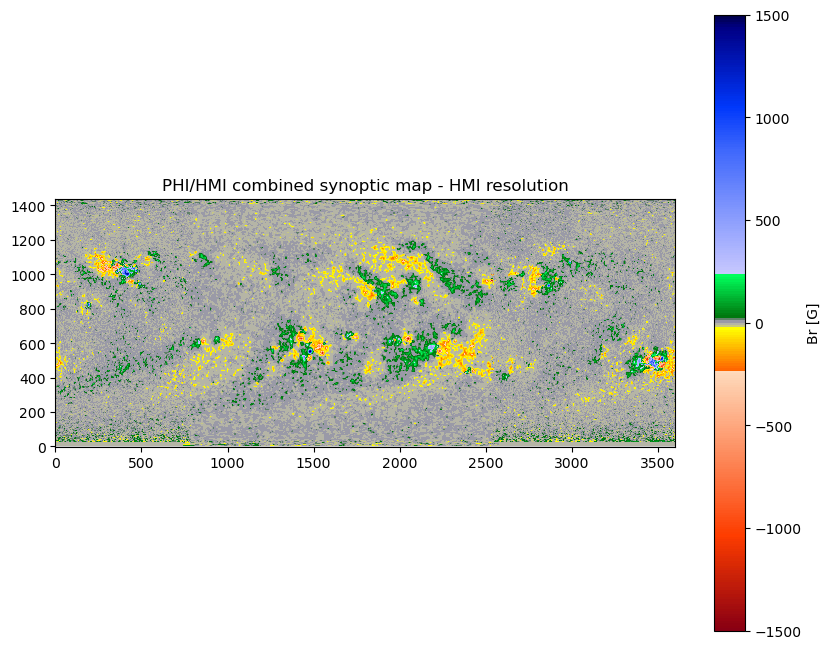

In [118]:
plt.close()
fig, ax = plt.subplots(figsize=(10, 8), nrows=1, ncols=1, sharex=True, sharey=True)
im1 = ax.imshow(phi_polfil_degr, vmin=-1500, vmax=1500, cmap="hmimag", interpolation='None', origin='lower', label='PHI CR')

ax.set_title('PHI/HMI combined synoptic map - HMI resolution')

ax.set_facecolor('lightgray')

fig.colorbar(im1, label='Br [G]')

## PFSS Tests

In [119]:
pfss(phi_polfil, synop_hmi, None, name=None, pdf=False)

2026-02-02 11:25:06 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs
 [sunpy.map.mapbase]
2026-02-02 11:25:06 - sunpy - WARNING: SunpyMetadataWarning: Missing metadata for observer: assuming Earth-based observer.
For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs



INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
Tracing field lines...


RuntimeError: Using FortranTracer requires the streamtracer module, but streamtracer could not be loaded

In [ ]:
pfss(phi_polfil_degr, synop_hmi, None, name=None, pdf=False)